In [101]:
# check installed version
# from pycaret.classification import *
import pandas as pd
import numpy as np
import duckdb
import pickle
from datetime import datetime
import math

def esql(query):
    return(duckdb.sql(query).df())

# pycaret.__version__
# pandas 2.1.0 pycaret 3.3.1 duckdb 0.10.2

In [102]:
tmp1 = pd.read_csv("c:\\Users\\jawoojk\\Desktop\\file\\tmp1.csv")
# dates를 SQL/시계열 처리에 안전한 날짜 타입으로 변환
tmp1['dates'] = pd.to_datetime(tmp1['dates'], errors='coerce').dt.date
tmp1.head()

,open,high,low,close,volume,adjusted,symbol,dates
0,53.889999,56.919998,53.889999,56.299999,2955600.0,53.076340,AAL,2007-01-03
1,56.299999,59.150002,53.650002,58.840000,2614500.0,55.470909,AAL,2007-01-04
2,58.830002,59.150002,57.900002,58.290001,1656300.0,54.952396,AAL,2007-01-05
3,57.299999,60.480000,57.040001,57.930000,2163200.0,54.613007,AAL,2007-01-08
4,59.439999,60.200001,57.560001,57.900002,2098600.0,54.584732,AAL,2007-01-09


In [103]:
print(tmp1.describe())
print("\n\n",tmp1.isna().sum())
print("\n\n",tmp1.dtypes)


               open          high           low         close        volume  \
count  2.204441e+06  2.204441e+06  2.204441e+06  2.204441e+06  2.204441e+06   
mean   6.050776e+01  6.138401e+01  5.960745e+01  6.050896e+01  4.925708e+06   
std    1.118063e+02  1.132096e+02  1.103716e+02  1.118090e+02  3.819374e+07   
min    5.000000e-02  5.666700e-02  4.666700e-02  5.000000e-02  1.000000e+00   
25%    1.687000e+01  1.716000e+01  1.656000e+01  1.686766e+01  2.202000e+05   
50%    3.300000e+01  3.350000e+01  3.248000e+01  3.300000e+01  6.479000e+05   
75%    6.609000e+01  6.705000e+01  6.513000e+01  6.610000e+01  2.051000e+06   
max    4.289000e+03  4.308000e+03  4.267240e+03  4.292000e+03  3.692928e+09   

           adjusted  
count  2.204441e+06  
mean   5.698542e+01  
std    1.109266e+02  
min    5.000000e-02  
25%    1.427200e+01  
50%    2.906048e+01  
75%    6.118468e+01  
max    4.292000e+03  


 open        0
high        0
low         0
close       0
volume      0
adjusted    0
sym

In [104]:
esql("select min(dates),max(dates) from tmp1")

,min(dates),max(dates)
0,2007-01-03,2024-10-10


In [105]:
print(esql("select symbol, min(dates), max(dates), count(*) from tmp1 group by symbol order by symbol"))


    symbol min(dates) max(dates)  count_star()
0      AAL 2007-01-03 2024-10-10          4474
1     AAON 2007-01-03 2024-10-10          4474
2     AAPL 2007-01-03 2024-10-10          4474
3     ABCB 2007-01-03 2024-10-10          4474
4     ACAD 2007-01-03 2024-10-10          4473
..     ...        ...        ...           ...
591   ZION 2007-01-03 2024-10-10          4474
592  ZIONO 2013-02-04 2024-10-10          2942
593  ZIONP 2007-01-05 2024-10-10          4158
594     ZM 2019-04-18 2024-10-10          1380
595     ZS 2018-03-16 2024-10-10          1654

[596 rows x 4 columns]


In [106]:
query="""select symbol, min(dates) min_date, max(dates) max_date, count(*) cnt from tmp1 
group by symbol having max(dates)>'2021-12-31' order by max_date"""
esql(query)

,symbol,min_date,max_date,cnt
0,LBTYB,2007-01-03,2024-10-07,1915
1,EWBC,2007-01-03,2024-10-10,4474
2,LRCX,2007-01-03,2024-10-10,4474
3,FITBI,2013-12-06,2024-10-10,2729
4,JD,2014-05-22,2024-10-10,2615
...,...,...,...,...
591,CACC,2007-01-03,2024-10-10,4474
592,MLKN,2007-01-03,2024-10-10,4474
593,MMSI,2007-01-03,2024-10-10,4474
594,MTCH,2007-01-03,2024-10-10,4474


In [107]:
# tmp1 기준으로 unique dates -> date_master(seq: 1부터) 생성
# 그리고 tmp1 + date_master 조인으로 tmp2 생성

date_master = (
    tmp1[['dates']]
    .dropna()
    .drop_duplicates()
    .sort_values('dates')
    .reset_index(drop=True)
)
date_master['seq'] = np.arange(1, len(date_master) + 1)

# dates로 결합
# many-to-one 관계 검증: tmp1의 여러 행이 date_master의 1개 날짜와 매칭
tmp2 = tmp1.merge(date_master, on='dates', how='left', validate='many_to_one')

# seq를 앞쪽으로 배치
tmp2 = tmp2[['seq'] + [c for c in tmp2.columns if c != 'seq']]

print("date_master shape:", date_master.shape)
print("tmp2 shape      :", tmp2.shape)
print("\n[date_master head]")
print(date_master.head())
print("\n[tmp2 head]")
print(tmp2.head())

date_master shape: (4474, 2)
tmp2 shape      : (2204441, 9)

[date_master head]
        dates  seq
0  2007-01-03    1
1  2007-01-04    2
2  2007-01-05    3
3  2007-01-08    4
4  2007-01-09    5

[tmp2 head]
   seq       open       high        low      close     volume   adjusted  \
0    1  53.889999  56.919998  53.889999  56.299999  2955600.0  53.076340   
1    2  56.299999  59.150002  53.650002  58.840000  2614500.0  55.470909   
2    3  58.830002  59.150002  57.900002  58.290001  1656300.0  54.952396   
3    4  57.299999  60.480000  57.040001  57.930000  2163200.0  54.613007   
4    5  59.439999  60.200001  57.560001  57.900002  2098600.0  54.584732   

  symbol       dates  
0    AAL  2007-01-03  
1    AAL  2007-01-04  
2    AAL  2007-01-05  
3    AAL  2007-01-08  
4    AAL  2007-01-09  


In [108]:
esql("select min(seq),max(seq) from tmp2")

,min(seq),max(seq)
0,1,4474


In [109]:
# ============================================================
# 공포탐욕지수 (Fear & Greed Index) 사전 계산
# → query123, query456, query_test 에서 공통 사용
# 구성: ① RSI(14)  ② 가격위치(52주)  ③ 변동성역수
#       ④ 캔들강도(20일)  ⑤ 거래량강도(20일)
# ============================================================

def calc_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0)
    loss  = (-delta).clip(lower=0)
    avg_g = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_l = loss.ewm(com=period - 1, min_periods=period).mean()
    rs    = avg_g / avg_l.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

def minmax_normalize(s, window=250, min_periods=30):
    s_min = s.rolling(window, min_periods=min_periods).min()
    s_max = s.rolling(window, min_periods=min_periods).max()
    return (s - s_min) / (s_max - s_min).replace(0, np.nan) * 100

def calc_fg_per_symbol(grp):
    g = grp.sort_values('seq').copy()
    components = []
    # ① RSI(14)
    components.append(calc_rsi(g['close'], 14))
    # ② 52주 가격 위치
    hi252     = g['close'].rolling(250, min_periods=30).max()
    lo252     = g['close'].rolling(250, min_periods=30).min()
    components.append((g['close'] - lo252) / (hi252 - lo252).replace(0, np.nan) * 100)
    # ③ 변동성 역수
    vol30   = g['close'].pct_change().rolling(30, min_periods=10).std() * 100
    components.append(100 - minmax_normalize(vol30))
    # ④ 캔들 강도: (종가-저가)/(고가-저가) 20일 이평
    hl      = (g['high'] - g['low']).replace(0, np.nan)
    components.append(((g['close'] - g['low']) / hl * 100).rolling(20, min_periods=5).mean())
    # ⑤ 거래량 강도: 상승일 거래량 비율 20일 이평
    up_vol  = g['volume'].where(g['close'] >= g['close'].shift(1), 0.0)
    vol_sum = g['volume'].rolling(20, min_periods=5).sum().replace(0, np.nan)
    components.append(up_vol.rolling(20, min_periods=5).sum() / vol_sum * 100)

    g['fear_greed'] = pd.concat(components, axis=1).mean(axis=1)
    return g[['symbol', 'seq', 'dates', 'open', 'high', 'low', 'close', 'volume', 'fear_greed']]

print("공포탐욕지수 계산 중...")
fg_all = (
    tmp2.sort_values(['symbol', 'seq'])
        .groupby('symbol', group_keys=False)
        .apply(calc_fg_per_symbol)
        .reset_index(drop=True)
)
print(f"완료: {len(fg_all):,}행  |  FGI 결측: {fg_all['fear_greed'].isna().sum():,}개")
# 기준일(train/test/deploy)별 FGI 분포 확인
fg_all[fg_all['seq'].isin([4411, 4432, 4453])].groupby('seq')['fear_greed'].describe().round(2)

공포탐욕지수 계산 중...


C:\Windows\Temp\ipykernel_19636\2232073795.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calc_fg_per_symbol)


완료: 2,204,441행  |  FGI 결측: 2,384개


,count,mean,std,min,25%,50%,75%,max
seq,,,,,,,,
4411,595.0,59.08,11.08,16.46,51.85,59.32,67.11,81.03
4432,595.0,45.71,12.22,17.31,36.63,46.17,54.91,78.57
4453,596.0,50.64,12.42,16.17,42.04,50.82,59.64,79.66


In [ ]:
# ## Feature 변수 설명 (query456 / query_test 기준)

# > **기준일**: train=seq 4411 / test=seq 4432 / deploy=seq 4453  
# > **타겟**: `(21일 평균종가 + 21일 최고가) / 2 / 기준일종가 > 1.05` → class=1


# ### 식별자 / 타겟
# | 변수명 | 설명 |
# |---|---|
# | `symbol` | 종목 코드 |
# | `close_train` | 기준일 종가 (raw price, seq=4411 기준) |
# | `train_class` | 타겟 레이블 (1: 21일 내 5% 이상 상승 기회, 0: 그 외) |

# ---

# ### 이동평균 (Moving Average)
# | 변수명 | 설명 |
# |---|---|
# | `avg_close_30` | 기준일 기준 최근 30거래일 종가 단순이동평균 |
# | `avg_close_60` | 최근 60거래일 종가 이동평균 |
# | `avg_close_90` | 최근 90거래일 종가 이동평균 |
# | `avg_close_120` | 최근 120거래일 종가 이동평균 |
# | `avg_close_150` | 최근 150거래일 종가 이동평균 |
# | `avg_close_180` | 최근 180거래일 종가 이동평균 |
# | `avg_close_210` | 최근 210거래일 종가 이동평균 |

# ---

# ### 이동평균 비율 (MA Ratio)
# | 변수명 | 설명 | 해석 |
# |---|---|---|
# | `avg_close_30_60` | MA30 / MA60 | 1 초과 → 단기 상승 추세 |
# | `avg_close_30_120` | MA30 / MA120 | 1 초과 → 중기 상승 추세 |
# | `ma20_60` | MA20 / MA60 | 골든크로스(>1) / 데드크로스(<1) 신호 |

# ---

# ### 모멘텀 (Momentum)
# | 변수명 | 설명 | 해석 |
# |---|---|---|
# | `momentum_1m` | 기준일 종가 / 21거래일 전 종가 | 1개월 수익률 대비 |
# | `momentum_3m` | 기준일 종가 / 63거래일 전 종가 | 3개월 수익률 대비 |
# | `momentum_6m` | 기준일 종가 / 126거래일 전 종가 | 6개월 수익률 대비 |
# | `momentum_12m` | 기준일 종가 / 252거래일 전 종가 | 12개월 수익률 대비 |

# ---

# ### 현재가 vs 이동평균 비율 (Price to MA)
# | 변수명 | 설명 | 해석 |
# |---|---|---|
# | `price_to_ma30` | 기준일 종가 / MA30 | 1 초과 → 단기 이평선 위 (강세) |
# | `price_to_ma60` | 기준일 종가 / MA60 | 1 초과 → 중기 이평선 위 |
# | `price_to_ma120` | 기준일 종가 / MA120 | 1 초과 → 장기 이평선 위 |

# ---

# ### 52주 고저가 대비 위치
# | 변수명 | 설명 | 해석 |
# |---|---|---|
# | `pct_from_52w_high` | 기준일 종가 / 250거래일 고가 | 1에 가까울수록 52주 고점 근처 |
# | `pct_from_52w_low` | 기준일 종가 / 250거래일 저가 | 높을수록 52주 저점 대비 많이 상승 |

# ---

# ### MA 기울기 (Slope)
# | 변수명 | 설명 | 해석 |
# |---|---|---|
# | `ma_slope_10` | 최근 10일 MA / 그 이전 10일 MA | 1 초과 → 단기 상승 방향성 |
# | `ma_slope_30` | 최근 30일 MA / 그 이전 30일 MA | 1 초과 → 중기 상승 방향성 |

# ---

# ### 고저가 기반 피처
# | 변수명 | 설명 | 해석 |
# |---|---|---|
# | `pct_from_60d_high` | 기준일 종가 / 60거래일 고가 | 1에 가까울수록 60일 신고가 근처 |
# | `avg_hl_range_30` | 30일 평균 (고가-저가)/종가 | 클수록 일중 변동성 높음 |

# ---

# ### 변동성 (Volatility)
# | 변수명 | 설명 | 해석 |
# |---|---|---|
# | `volatility_30` | 30일 종가 표준편차 / 30일 평균 (변동계수 CV) | 종목 간 스케일 제거한 상대 변동성 |
# | `std_close_30` | 30일 종가의 표준편차 (절대값) | 원화 기준 가격 산포도 |
# | `std_close_30_pct` | std_close_30 / 기준일 종가 × 100 | 현재가 기준 % 변동폭 (volatility_30의 변형) |


# ### 공포탐욕지수 (Fear & Greed Index)
# | 변수명 | 설명 |
# |---|---|
# | `fear_greed` | 5개 지표 합산 점수 (0~100) |

# **구성 요소 (각 0~100, 단순 평균):**
# 1. RSI(14) — 단기 과매수/과매도
# 2. 52주 가격 위치 — 고저가 범위 내 현재가 백분위
# 3. 변동성 역수 — 30일 변동성 낮을수록 탐욕(안정)
# 4. 캔들 강도 — `(종가-저가)/(고가-저가)` 20일 이평
# 5. 거래량 강도 — 상승일 거래량 비율 20일 이평

# > 0~15: 극단적 공포 / 16~30: 공포 / 31~55: 중립 / 56~75: 탐욕 / 76~100: 극단적 탐욕


In [110]:
query123="""
select t.*,
    ft.fear_greed    AS fg_train,
    ftest.fear_greed AS fg_test,
    fd.fear_greed    AS fg_deploy
from (
    select symbol,
    max(case when seq=4411 then close else null end) close_train,
    avg(case when seq between 4412 and 4432 then close else null end) avg_train,
    max(case when seq between 4412 and 4432 then close else null end) max_train,

    max(case when seq=4432 then close else null end) close_test,
    avg(case when seq between 4433 and 4453 then close else null end) avg_test,
    max(case when seq between 4433 and 4453 then close else null end) max_test,

    max(case when seq=4453 then close else null end) close_deploy,
    avg(case when seq between 4454 and 4474 then close else null end) avg_deploy,
    max(case when seq between 4454 and 4474 then close else null end) max_deploy,

    (avg(case when seq between 4412 and 4432 then close else null end) +
     max(case when seq between 4412 and 4432 then close else null end)) / 2 /
    max(case when seq=4411 then close else null end) train_target_ratio,

    (avg(case when seq between 4433 and 4453 then close else null end) +
     max(case when seq between 4433 and 4453 then close else null end)) / 2 /
    max(case when seq=4432 then close else null end) test_target_ratio,

    (avg(case when seq between 4454 and 4474 then close else null end) +
     max(case when seq between 4454 and 4474 then close else null end)) / 2 /
    max(case when seq=4453 then close else null end) deploy_target_ratio

    from tmp2
    group by symbol
) t
-- 공포탐욕지수: train(seq=4411), test(seq=4432), deploy(seq=4453) 기준일 FGI
left join (select symbol, fear_greed from fg_all where seq=4411) ft    on t.symbol = ft.symbol
left join (select symbol, fear_greed from fg_all where seq=4432) ftest on t.symbol = ftest.symbol
left join (select symbol, fear_greed from fg_all where seq=4453) fd    on t.symbol = fd.symbol
order by deploy_target_ratio desc
"""
tmp3=esql(query123)
print(tmp3[['symbol','close_train','train_target_ratio','fg_train','fg_test','fg_deploy']].head())

  symbol  close_train  train_target_ratio   fg_train    fg_test  fg_deploy
0   FUTU    68.570000            0.937813  55.876942  43.910097  48.758318
1   BILI    16.709999            0.933202  59.400172  52.000844  55.915656
2     JD    28.150000            0.947035  49.871000  50.314090  48.181873
3    PDD   142.419998            0.964239  62.298765  62.831805  24.298557
4     WB     8.500000            0.942745  51.262515  47.600617  41.878632


In [111]:
query="""select a.*, 
case when train_target_ratio>1.05 then 1 else 0 end as train_class,
case when test_target_ratio>1.05 then 1 else 0 end as test_class, 
case when deploy_target_ratio>1.05 then 1 else 0 end as deploy_class 
from tmp3 a"""

tmp4=esql(query)
print(tmp4.head())
print(tmp4.tail())

  symbol  close_train   avg_train   max_train  close_test    avg_test  \
0   FUTU    68.570000   60.931667   67.680000   58.880001   60.860952   
1   BILI    16.709999   15.087619   16.100000   13.490000   14.354286   
2     JD    28.150000   26.118095   27.200001   26.070000   26.782857   
3    PDD   142.419998  132.183810  142.470001  142.470001  116.218095   
4     WB     8.500000    7.786667    8.240000    8.190000    7.619048   

     max_test  close_deploy  avg_deploy  max_deploy  train_target_ratio  \
0   63.560001     59.610001   87.430952  128.929993            0.937813   
1   15.630000     15.630000   20.603333   29.660000            0.933202   
2   29.540001     26.559999   36.240953   47.080002            0.947035   
3  151.110001     95.279999  123.899048  154.270004            0.964239   
4    8.350000      7.230000    9.168571   11.710000            0.942745   

   test_target_ratio  deploy_target_ratio   fg_train    fg_test  fg_deploy  \
0           1.056564            

In [112]:
print(esql("select train_class, count(*) from tmp4 group by train_class order by train_class"))
print("\n")
print(esql("select test_class, count(*) from tmp4 group by test_class order by test_class"))
print("\n")
print(esql("select deploy_class, count(*) from tmp4 group by deploy_class order by deploy_class"))

   train_class  count_star()
0            0           390
1            1           206


   test_class  count_star()
0           0           249
1           1           347


   deploy_class  count_star()
0             0           279
1             1           317


In [113]:
query456="""
select b.symbol, train_class, b.close_train,
    a.avg_close_30, avg_close_60, avg_close_90, avg_close_120,
    avg_close_150, avg_close_180, avg_close_210,
    avg_close_30_60, avg_close_30_120,
    -- 7. 20일MA / 60일MA 비율 (골든크로스/데드크로스 신호)
    ma20_60,
    -- 1. 모멘텀 비율 (1M/3M/6M/12M)
    momentum_1m, momentum_3m, momentum_6m, momentum_12m,
    -- 2. 현재가 vs MA 비율
    price_to_ma30, price_to_ma60, price_to_ma120,
    -- 3. 52주 고가/저가 대비 위치
    pct_from_52w_high, pct_from_52w_low,
    -- 4. MA 기울기
    ma_slope_10, ma_slope_30,
    -- 5. 고가/저가 기반 피처
    pct_from_60d_high, avg_hl_range_30,
    -- 6. 변동성 (변동계수: std/avg)
    volatility_30,
    -- 9. 종가 표준편차 기반 변동성
    std_close_30,       -- 30일 종가 표준편차 (절대값)
    std_close_30_pct,   -- 30일 종가 표준편차 / 기준일 종가 × 100 (% 변동폭)
    -- 8. 공포탐욕지수 (train 기준일 seq=4411)
    b.fg_train AS fear_greed
from (
    select symbol,
    avg(case when seq between 4411-30  and 4411 then close else null end) avg_close_30,
    avg(case when seq between 4411-60  and 4411 then close else null end) avg_close_60,
    avg(case when seq between 4411-90  and 4411 then close else null end) avg_close_90,
    avg(case when seq between 4411-120 and 4411 then close else null end) avg_close_120,
    avg(case when seq between 4411-150 and 4411 then close else null end) avg_close_150,
    avg(case when seq between 4411-180 and 4411 then close else null end) avg_close_180,
    avg(case when seq between 4411-210 and 4411 then close else null end) avg_close_210,
    avg(case when seq between 4411-30  and 4411 then close else null end) /
        avg(case when seq between 4411-60  and 4411 then close else null end) avg_close_30_60,
    avg(case when seq between 4411-30  and 4411 then close else null end) /
        avg(case when seq between 4411-120 and 4411 then close else null end) avg_close_30_120,
    -- 7. 20일MA / 60일MA 비율: 1보다 크면 골든크로스(상승 추세), 작으면 데드크로스(하락 추세)
    avg(case when seq between 4411-20 and 4411 then close else null end) /
        avg(case when seq between 4411-60 and 4411 then close else null end) ma20_60,
    -- 1. 모멘텀 비율: 기준일 종가 / N일 전 종가
    max(case when seq=4411     then close else null end) /
        max(case when seq=4411-21  then close else null end) momentum_1m,
    max(case when seq=4411     then close else null end) /
        max(case when seq=4411-63  then close else null end) momentum_3m,
    max(case when seq=4411     then close else null end) /
        max(case when seq=4411-126 then close else null end) momentum_6m,
    max(case when seq=4411     then close else null end) /
        max(case when seq=4411-252 then close else null end) momentum_12m,
    -- 2. 현재가 vs MA 비율: 과매수/과매도 신호
    max(case when seq=4411 then close else null end) /
        avg(case when seq between 4411-30  and 4411 then close else null end) price_to_ma30,
    max(case when seq=4411 then close else null end) /
        avg(case when seq between 4411-60  and 4411 then close else null end) price_to_ma60,
    max(case when seq=4411 then close else null end) /
        avg(case when seq between 4411-120 and 4411 then close else null end) price_to_ma120,
    -- 3. 52주(250거래일) 고가/저가 대비 위치
    max(case when seq=4411 then close else null end) /
        max(case when seq between 4411-250 and 4411 then close else null end) pct_from_52w_high,
    max(case when seq=4411 then close else null end) /
        min(case when seq between 4411-250 and 4411 then close else null end) pct_from_52w_low,
    -- 4. MA 기울기: 단기 방향성
    avg(case when seq between 4411-10 and 4411    then close else null end) /
        avg(case when seq between 4411-20 and 4411-10 then close else null end) ma_slope_10,
    avg(case when seq between 4411-30 and 4411    then close else null end) /
        avg(case when seq between 4411-60 and 4411-30 then close else null end) ma_slope_30,
    -- 5. 고가/저가 기반 피처
    max(case when seq=4411 then close else null end) /
        max(case when seq between 4411-60 and 4411 then high else null end) pct_from_60d_high,
    avg(case when seq between 4411-30 and 4411 then (high - low) / close else null end) avg_hl_range_30,
    -- 6. 변동성: 수익률 표준편차 / 평균 (변동계수)
    stddev(case when seq between 4411-30 and 4411 then close else null end) /
        avg(case when seq between 4411-30  and 4411 then close else null end) volatility_30,
    -- 9. 종가 표준편차 기반 변동성
    -- std_close_30: 30일 종가의 순수 표준편차 (절대값, 종목 간 스케일 차이 있음)
    stddev(case when seq between 4411-30 and 4411 then close else null end) std_close_30,
    -- std_close_30_pct: 표준편차 / 기준일 종가 × 100 → 현재가 기준 % 변동폭
    --   volatility_30(std/avg)과의 차이: 평균가 대신 현재 종가로 정규화
    stddev(case when seq between 4411-30 and 4411 then close else null end) /
        max(case when seq=4411 then close else null end) * 100 std_close_30_pct
    from tmp2 group by symbol
) a, tmp4 b
where a.symbol=b.symbol order by b.symbol
"""
tmp5=esql(query456)
tmp5

,symbol,train_class,close_train,avg_close_30,avg_close_60,avg_close_90,avg_close_120,avg_close_150,avg_close_180,avg_close_210,...,pct_from_52w_high,pct_from_52w_low,ma_slope_10,ma_slope_30,pct_from_60d_high,avg_hl_range_30,volatility_30,std_close_30,std_close_30_pct,fear_greed
0,AAL,0,10.680000,11.259032,12.689836,13.228681,13.615124,13.667351,13.373812,13.269763,...,0.571734,1.000000,0.977916,0.799299,0.695313,0.025346,0.021608,0.243288,2.277977,41.247411
1,AAON,0,90.029999,79.960001,81.060328,82.410989,81.243554,79.154239,75.882210,73.328531,...,0.953001,1.703500,1.078268,0.975586,0.934503,0.031289,0.074212,5.933972,6.591105,71.347344
2,AAPL,0,230.539993,210.494516,195.147377,187.421538,187.243140,187.935364,187.050221,185.437583,...,0.989527,1.397212,1.053475,1.171734,0.989102,0.021998,0.061717,12.991067,5.635060,57.208669
3,ABCB,1,54.529999,48.890968,48.649672,48.020659,48.146446,48.621788,47.295470,45.991801,...,1.000000,1.550469,1.058240,1.011108,0.980403,0.025594,0.040668,1.988291,3.646234,65.140324
4,ACAD,0,17.770000,15.650968,15.907049,17.029231,19.212727,20.967682,21.242597,21.546588,...,0.530923,1.215458,1.081434,0.970807,0.982854,0.031784,0.054127,0.847142,4.767258,54.872819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,ZION,1,47.230000,42.482903,42.571639,42.183736,41.825537,41.915828,40.540829,39.705877,...,0.995993,1.603735,1.059657,0.996504,0.990770,0.022765,0.039919,1.695889,3.590704,73.940699
592,ZIONO,0,25.450001,25.433871,25.530328,25.493956,25.627686,25.611126,25.546961,25.483175,...,0.922436,1.026210,0.996321,0.992110,0.980354,0.005460,0.005698,0.144929,0.569467,50.091979
593,ZIONP,1,21.270000,21.299152,20.914574,20.631459,20.536106,20.382123,20.148046,20.041245,...,0.915232,1.201016,1.020395,1.034924,0.867738,0.023653,0.025254,0.537884,2.528836,47.131796
594,ZM,0,57.580002,59.244839,60.615574,62.243626,63.110909,64.564437,64.354420,64.757725,...,0.775906,1.028214,0.997493,0.955403,0.880428,0.021452,0.037095,2.197680,3.816742,42.036541


In [114]:
tmp5.columns

Index(['symbol', 'train_class', 'close_train', 'avg_close_30', 'avg_close_60',
       'avg_close_90', 'avg_close_120', 'avg_close_150', 'avg_close_180',
       'avg_close_210', 'avg_close_30_60', 'avg_close_30_120', 'ma20_60',
       'momentum_1m', 'momentum_3m', 'momentum_6m', 'momentum_12m',
       'price_to_ma30', 'price_to_ma60', 'price_to_ma120', 'pct_from_52w_high',
       'pct_from_52w_low', 'ma_slope_10', 'ma_slope_30', 'pct_from_60d_high',
       'avg_hl_range_30', 'volatility_30', 'std_close_30', 'std_close_30_pct',
       'fear_greed'],
      dtype='object')

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, f1_score)
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
    VotingClassifier,
)

In [116]:
tmp6=tmp5.copy()

In [117]:
X_train = tmp6.drop(['train_class','symbol'], axis=1)
y_train = tmp6['train_class']

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)


In [118]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train_sc, y_train)

y_pred_dt = dt.predict(X_train_sc)
print(f"Accuracy : {accuracy_score(y_train, y_pred_dt):.4f}")
print(classification_report(y_train, y_pred_dt,target_names=['0', '1']))

Accuracy : 0.7601
              precision    recall  f1-score   support

           0       0.79      0.86      0.82       390
           1       0.68      0.57      0.62       206

    accuracy                           0.76       596
   macro avg       0.74      0.72      0.72       596
weighted avg       0.75      0.76      0.75       596



In [119]:
fi_dt = pd.Series(dt.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Feature Importance:")
print(fi_dt)

Feature Importance:
std_close_30         0.363608
avg_close_30_120     0.133003
price_to_ma60        0.086144
avg_close_30_60      0.072443
momentum_1m          0.068920
fear_greed           0.067585
ma_slope_10          0.049169
ma_slope_30          0.042401
pct_from_52w_low     0.038946
avg_close_30         0.030646
momentum_12m         0.026625
momentum_6m          0.020511
ma20_60              0.000000
avg_close_150        0.000000
avg_close_180        0.000000
avg_close_210        0.000000
avg_close_120        0.000000
close_train          0.000000
avg_close_60         0.000000
avg_close_90         0.000000
pct_from_52w_high    0.000000
price_to_ma120       0.000000
momentum_3m          0.000000
price_to_ma30        0.000000
avg_hl_range_30      0.000000
pct_from_60d_high    0.000000
volatility_30        0.000000
std_close_30_pct     0.000000
dtype: float64


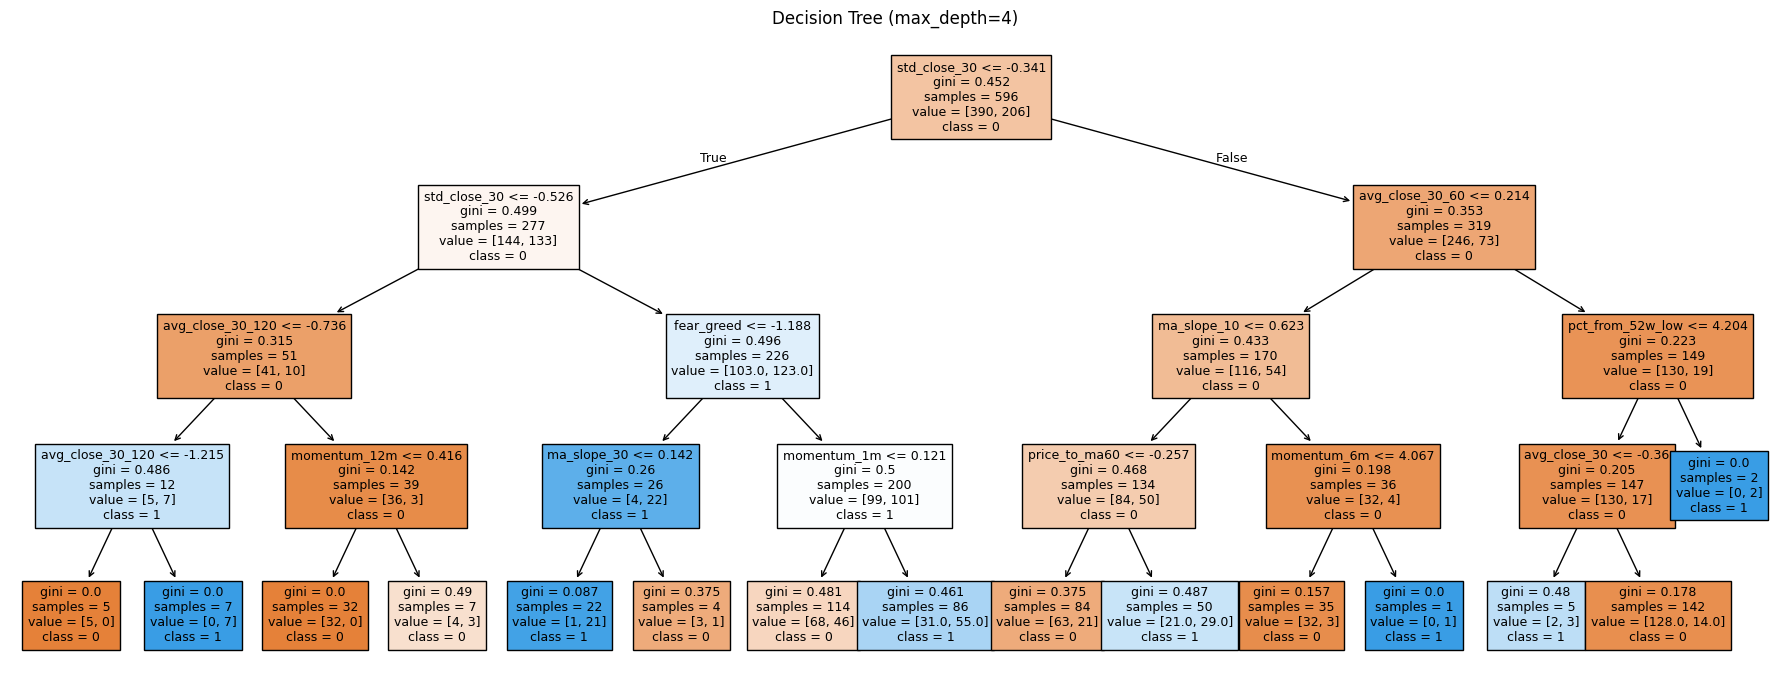

In [120]:
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(
    dt,
    feature_names=X_train.columns.tolist(),
    class_names=['0', '1'],
    filled=True,
    fontsize=9,
    ax=ax,
)
ax.set_title("Decision Tree (max_depth=4)")
fig.tight_layout()
plt.show()

In [121]:
train_result=pd.concat([tmp6, pd.DataFrame(y_pred_dt, columns=['y_pred_dt'])], axis=1)
train_result.head()

,symbol,train_class,close_train,avg_close_30,avg_close_60,avg_close_90,avg_close_120,avg_close_150,avg_close_180,avg_close_210,...,pct_from_52w_low,ma_slope_10,ma_slope_30,pct_from_60d_high,avg_hl_range_30,volatility_30,std_close_30,std_close_30_pct,fear_greed,y_pred_dt
0,AAL,0,10.680000,11.259032,12.689836,13.228681,13.615124,13.667351,13.373812,13.269763,...,1.000000,0.977916,0.799299,0.695313,0.025346,0.021608,0.243288,2.277977,41.247411,0
1,AAON,0,90.029999,79.960001,81.060328,82.410989,81.243554,79.154239,75.882210,73.328531,...,1.703500,1.078268,0.975586,0.934503,0.031289,0.074212,5.933972,6.591105,71.347344,0
2,AAPL,0,230.539993,210.494516,195.147377,187.421538,187.243140,187.935364,187.050221,185.437583,...,1.397212,1.053475,1.171734,0.989102,0.021998,0.061717,12.991067,5.635060,57.208669,0
3,ABCB,1,54.529999,48.890968,48.649672,48.020659,48.146446,48.621788,47.295470,45.991801,...,1.550469,1.058240,1.011108,0.980403,0.025594,0.040668,1.988291,3.646234,65.140324,0
4,ACAD,0,17.770000,15.650968,15.907049,17.029231,19.212727,20.967682,21.242597,21.546588,...,1.215458,1.081434,0.970807,0.982854,0.031784,0.054127,0.847142,4.767258,54.872819,1


In [122]:
esql("select y_pred_dt, train_class, count(*) cnt from train_result group by y_pred_dt, train_class order by y_pred_dt, train_class")

,y_pred_dt,train_class,cnt
0,0,0,335
1,0,1,88
2,1,0,55
3,1,1,118


In [123]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_train, y_pred_dt)
recall    = recall_score(y_train, y_pred_dt)
baseline  = y_train.mean()

print(f"precision : {precision:.4f}")
print(f"recall    : {recall:.4f}")
print(f"baseline  : {baseline:.4f}")


precision : 0.6821
recall    : 0.5728
baseline  : 0.3456


In [124]:
query_test="""
select b.symbol, test_class, b.close_test close_train,
    a.avg_close_30, avg_close_60, avg_close_90, avg_close_120,
    avg_close_150, avg_close_180, avg_close_210,
    avg_close_30_60, avg_close_30_120,
    -- 7. 20일MA / 60일MA 비율 (골든크로스/데드크로스 신호)
    ma20_60,
    -- 1. 모멘텀 비율 (1M/3M/6M/12M)
    momentum_1m, momentum_3m, momentum_6m, momentum_12m,
    -- 2. 현재가 vs MA 비율
    price_to_ma30, price_to_ma60, price_to_ma120,
    -- 3. 52주 고가/저가 대비 위치
    pct_from_52w_high, pct_from_52w_low,
    -- 4. MA 기울기
    ma_slope_10, ma_slope_30,
    -- 5. 고가/저가 기반 피처
    pct_from_60d_high, avg_hl_range_30,
    -- 6. 변동성 (변동계수: std/avg)
    volatility_30,
    -- 9. 종가 표준편차 기반 변동성
    std_close_30,       -- 30일 종가 표준편차 (절대값)
    std_close_30_pct,   -- 30일 종가 표준편차 / 기준일 종가 × 100 (% 변동폭)
    -- 8. 공포탐욕지수 (test 기준일 seq=4432)
    b.fg_test AS fear_greed
from (
    select symbol,
    avg(case when seq between 4432-30  and 4432 then close else null end) avg_close_30,
    avg(case when seq between 4432-60  and 4432 then close else null end) avg_close_60,
    avg(case when seq between 4432-90  and 4432 then close else null end) avg_close_90,
    avg(case when seq between 4432-120 and 4432 then close else null end) avg_close_120,
    avg(case when seq between 4432-150 and 4432 then close else null end) avg_close_150,
    avg(case when seq between 4432-180 and 4432 then close else null end) avg_close_180,
    avg(case when seq between 4432-210 and 4432 then close else null end) avg_close_210,
    avg(case when seq between 4432-30  and 4432 then close else null end) /
        avg(case when seq between 4432-60  and 4432 then close else null end) avg_close_30_60,
    avg(case when seq between 4432-30  and 4432 then close else null end) /
        avg(case when seq between 4432-120 and 4432 then close else null end) avg_close_30_120,
    -- 7. 20일MA / 60일MA 비율: 1보다 크면 골든크로스(상승 추세), 작으면 데드크로스(하락 추세)
    avg(case when seq between 4432-20 and 4432 then close else null end) /
        avg(case when seq between 4432-60 and 4432 then close else null end) ma20_60,
    -- 1. 모멘텀 비율: 기준일 종가 / N일 전 종가
    max(case when seq=4432     then close else null end) /
        max(case when seq=4432-21  then close else null end) momentum_1m,
    max(case when seq=4432     then close else null end) /
        max(case when seq=4432-63  then close else null end) momentum_3m,
    max(case when seq=4432     then close else null end) /
        max(case when seq=4432-126 then close else null end) momentum_6m,
    max(case when seq=4432     then close else null end) /
        max(case when seq=4432-252 then close else null end) momentum_12m,
    -- 2. 현재가 vs MA 비율: 과매수/과매도 신호
    max(case when seq=4432 then close else null end) /
        avg(case when seq between 4432-30  and 4432 then close else null end) price_to_ma30,
    max(case when seq=4432 then close else null end) /
        avg(case when seq between 4432-60  and 4432 then close else null end) price_to_ma60,
    max(case when seq=4432 then close else null end) /
        avg(case when seq between 4432-120 and 4432 then close else null end) price_to_ma120,
    -- 3. 52주(250거래일) 고가/저가 대비 위치
    max(case when seq=4432 then close else null end) /
        max(case when seq between 4432-250 and 4432 then close else null end) pct_from_52w_high,
    max(case when seq=4432 then close else null end) /
        min(case when seq between 4432-250 and 4432 then close else null end) pct_from_52w_low,
    -- 4. MA 기울기: 단기 방향성
    avg(case when seq between 4432-10 and 4432    then close else null end) /
        avg(case when seq between 4432-20 and 4432-10 then close else null end) ma_slope_10,
    avg(case when seq between 4432-30 and 4432    then close else null end) /
        avg(case when seq between 4432-60 and 4432-30 then close else null end) ma_slope_30,
    -- 5. 고가/저가 기반 피처
    max(case when seq=4432 then close else null end) /
        max(case when seq between 4432-60 and 4432 then high else null end) pct_from_60d_high,
    avg(case when seq between 4432-30 and 4432 then (high - low) / close else null end) avg_hl_range_30,
    -- 6. 변동성: 수익률 표준편차 / 평균 (변동계수)
    stddev(case when seq between 4432-30 and 4432 then close else null end) /
        avg(case when seq between 4432-30  and 4432 then close else null end) volatility_30,
    -- 9. 종가 표준편차 기반 변동성
    -- std_close_30: 30일 종가의 순수 표준편차 (절대값, 종목 간 스케일 차이 있음)
    stddev(case when seq between 4432-30 and 4432 then close else null end) std_close_30,
    -- std_close_30_pct: 표준편차 / 기준일 종가 × 100 → 현재가 기준 % 변동폭
    --   volatility_30(std/avg)과의 차이: 평균가 대신 현재 종가로 정규화
    stddev(case when seq between 4432-30 and 4432 then close else null end) /
        max(case when seq=4432 then close else null end) * 100 std_close_30_pct
    from tmp2 group by symbol
) a, tmp4 b
where a.symbol=b.symbol order by b.symbol
"""
tmp7=esql(query_test)
tmp7

,symbol,test_class,close_train,avg_close_30,avg_close_60,avg_close_90,avg_close_120,avg_close_150,avg_close_180,avg_close_210,...,pct_from_52w_high,pct_from_52w_low,ma_slope_10,ma_slope_30,pct_from_60d_high,avg_hl_range_30,volatility_30,std_close_30,std_close_30_pct,fear_greed
0,AAL,1,9.610000,10.498387,11.354754,12.221978,12.865207,13.162119,13.211602,12.996919,...,0.605164,1.037797,0.929841,0.859796,0.630164,0.034976,0.057205,0.600561,6.249338,33.075364
1,AAON,1,87.389999,87.153871,82.008853,83.272088,83.413967,81.534636,79.328398,76.202085,...,0.923589,1.653548,0.979949,1.131390,0.923101,0.036449,0.025228,2.198746,2.516016,52.748544
2,AAPL,0,217.529999,221.400323,210.757213,198.489121,192.661488,191.663775,191.771436,189.925024,...,0.926369,1.318364,0.960673,1.106395,0.916958,0.025150,0.033062,7.320013,3.365059,51.142587
3,ABCB,1,55.660000,56.077097,52.236066,50.684505,49.674628,49.729470,49.494254,48.015782,...,0.901961,1.582599,0.964396,1.160195,0.857892,0.036156,0.073426,4.117506,7.397603,49.743614
4,ACAD,1,15.290000,17.493226,16.367541,16.553736,17.758099,19.626954,20.682762,20.992559,...,0.481272,1.045828,0.956582,1.147995,0.786523,0.037831,0.074194,1.297884,8.488449,36.262404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,ZION,1,45.490002,47.531935,44.948361,43.993407,43.146694,42.886093,42.429061,41.133934,...,0.865981,1.544652,0.945925,1.123318,0.853151,0.031262,0.067406,3.203949,7.043194,50.569871
592,ZIONO,0,25.590000,25.524839,25.555738,25.524176,25.520248,25.620265,25.606298,25.526967,...,0.927510,1.031855,1.003237,0.997969,0.985747,0.004130,0.005049,0.128864,0.503570,56.917027
593,ZIONP,0,21.945499,21.897719,21.662330,21.100517,20.906960,20.695041,20.557276,20.287447,...,0.944299,1.239159,1.019261,1.022352,0.895296,0.019697,0.021593,0.472841,2.154616,57.162432
594,ZM,1,55.320000,58.159194,59.560410,60.278077,61.816157,62.757848,63.954061,63.722157,...,0.745452,1.000000,0.974610,0.954217,0.845872,0.021059,0.027139,1.578384,2.853189,41.520890


In [125]:
X_test = tmp7.drop(['test_class','symbol'], axis=1)
y_test = tmp7['test_class']

X_test_sc = scaler.transform(X_test)

y_pred_dt = dt.predict(X_test_sc)
print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt,target_names=['0', '1']))

Accuracy : 0.4446
              precision    recall  f1-score   support

           0       0.42      0.82      0.55       249
           1       0.58      0.17      0.27       347

    accuracy                           0.44       596
   macro avg       0.50      0.50      0.41       596
weighted avg       0.51      0.44      0.39       596



In [126]:
test_result=pd.concat([tmp7, pd.DataFrame(y_pred_dt, columns=['y_pred_dt'])], axis=1)
test_result.head()

,symbol,test_class,close_train,avg_close_30,avg_close_60,avg_close_90,avg_close_120,avg_close_150,avg_close_180,avg_close_210,...,pct_from_52w_low,ma_slope_10,ma_slope_30,pct_from_60d_high,avg_hl_range_30,volatility_30,std_close_30,std_close_30_pct,fear_greed,y_pred_dt
0,AAL,1,9.610000,10.498387,11.354754,12.221978,12.865207,13.162119,13.211602,12.996919,...,1.037797,0.929841,0.859796,0.630164,0.034976,0.057205,0.600561,6.249338,33.075364,1
1,AAON,1,87.389999,87.153871,82.008853,83.272088,83.413967,81.534636,79.328398,76.202085,...,1.653548,0.979949,1.131390,0.923101,0.036449,0.025228,2.198746,2.516016,52.748544,0
2,AAPL,0,217.529999,221.400323,210.757213,198.489121,192.661488,191.663775,191.771436,189.925024,...,1.318364,0.960673,1.106395,0.916958,0.025150,0.033062,7.320013,3.365059,51.142587,0
3,ABCB,1,55.660000,56.077097,52.236066,50.684505,49.674628,49.729470,49.494254,48.015782,...,1.582599,0.964396,1.160195,0.857892,0.036156,0.073426,4.117506,7.397603,49.743614,0
4,ACAD,1,15.290000,17.493226,16.367541,16.553736,17.758099,19.626954,20.682762,20.992559,...,1.045828,0.956582,1.147995,0.786523,0.037831,0.074194,1.297884,8.488449,36.262404,0


In [127]:
esql("select y_pred_dt, test_class, count(*) cnt from test_result group by y_pred_dt, test_class order by y_pred_dt, test_class")

,y_pred_dt,test_class,cnt
0,0,0,205
1,0,1,287
2,1,0,44
3,1,1,60


In [128]:
rf = RandomForestClassifier(n_estimators=500, max_depth=5, class_weight='balanced',random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf,target_names=['0', '1']))

Accuracy : 0.4245
              precision    recall  f1-score   support

           0       0.40      0.76      0.52       249
           1       0.52      0.19      0.27       347

    accuracy                           0.42       596
   macro avg       0.46      0.47      0.40       596
weighted avg       0.47      0.42      0.38       596



In [129]:
fi_rf = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Feature Importance:")
print(fi_rf)

Feature Importance:
std_close_30         0.087201
ma_slope_30          0.063466
std_close_30_pct     0.059057
volatility_30        0.059049
avg_hl_range_30      0.053561
ma20_60              0.052626
avg_close_30_60      0.052016
avg_close_30_120     0.040396
momentum_1m          0.039647
price_to_ma30        0.032786
momentum_6m          0.032642
pct_from_52w_low     0.032410
ma_slope_10          0.031774
price_to_ma60        0.031123
pct_from_52w_high    0.030273
fear_greed           0.029929
price_to_ma120       0.028031
momentum_3m          0.026350
momentum_12m         0.024273
avg_close_60         0.023953
avg_close_30         0.023040
pct_from_60d_high    0.022720
avg_close_210        0.022543
close_train          0.021958
avg_close_150        0.021299
avg_close_120        0.020370
avg_close_180        0.020086
avg_close_90         0.017418
dtype: float64


In [130]:
test_result=pd.concat([tmp7, pd.DataFrame(y_pred_rf, columns=['y_pred_dt'])], axis=1)
test_result.head()

,symbol,test_class,close_train,avg_close_30,avg_close_60,avg_close_90,avg_close_120,avg_close_150,avg_close_180,avg_close_210,...,pct_from_52w_low,ma_slope_10,ma_slope_30,pct_from_60d_high,avg_hl_range_30,volatility_30,std_close_30,std_close_30_pct,fear_greed,y_pred_dt
0,AAL,1,9.610000,10.498387,11.354754,12.221978,12.865207,13.162119,13.211602,12.996919,...,1.037797,0.929841,0.859796,0.630164,0.034976,0.057205,0.600561,6.249338,33.075364,1
1,AAON,1,87.389999,87.153871,82.008853,83.272088,83.413967,81.534636,79.328398,76.202085,...,1.653548,0.979949,1.131390,0.923101,0.036449,0.025228,2.198746,2.516016,52.748544,0
2,AAPL,0,217.529999,221.400323,210.757213,198.489121,192.661488,191.663775,191.771436,189.925024,...,1.318364,0.960673,1.106395,0.916958,0.025150,0.033062,7.320013,3.365059,51.142587,0
3,ABCB,1,55.660000,56.077097,52.236066,50.684505,49.674628,49.729470,49.494254,48.015782,...,1.582599,0.964396,1.160195,0.857892,0.036156,0.073426,4.117506,7.397603,49.743614,0
4,ACAD,1,15.290000,17.493226,16.367541,16.553736,17.758099,19.626954,20.682762,20.992559,...,1.045828,0.956582,1.147995,0.786523,0.037831,0.074194,1.297884,8.488449,36.262404,1


In [131]:
esql("select y_pred_dt, test_class, count(*) cnt from test_result group by y_pred_dt, test_class order by y_pred_dt, test_class")

,y_pred_dt,test_class,cnt
0,0,0,188
1,0,1,282
2,1,0,61
3,1,1,65


In [132]:
test_result=pd.concat([tmp7, pd.DataFrame(y_pred_dt, columns=['y_pred_dt']), pd.DataFrame(y_pred_rf, columns=['y_pred_rf'])], axis=1)
test_result.head()

,symbol,test_class,close_train,avg_close_30,avg_close_60,avg_close_90,avg_close_120,avg_close_150,avg_close_180,avg_close_210,...,ma_slope_10,ma_slope_30,pct_from_60d_high,avg_hl_range_30,volatility_30,std_close_30,std_close_30_pct,fear_greed,y_pred_dt,y_pred_rf
0,AAL,1,9.610000,10.498387,11.354754,12.221978,12.865207,13.162119,13.211602,12.996919,...,0.929841,0.859796,0.630164,0.034976,0.057205,0.600561,6.249338,33.075364,1,1
1,AAON,1,87.389999,87.153871,82.008853,83.272088,83.413967,81.534636,79.328398,76.202085,...,0.979949,1.131390,0.923101,0.036449,0.025228,2.198746,2.516016,52.748544,0,0
2,AAPL,0,217.529999,221.400323,210.757213,198.489121,192.661488,191.663775,191.771436,189.925024,...,0.960673,1.106395,0.916958,0.025150,0.033062,7.320013,3.365059,51.142587,0,0
3,ABCB,1,55.660000,56.077097,52.236066,50.684505,49.674628,49.729470,49.494254,48.015782,...,0.964396,1.160195,0.857892,0.036156,0.073426,4.117506,7.397603,49.743614,0,0
4,ACAD,1,15.290000,17.493226,16.367541,16.553736,17.758099,19.626954,20.682762,20.992559,...,0.956582,1.147995,0.786523,0.037831,0.074194,1.297884,8.488449,36.262404,0,1


In [133]:
query="""select case when y_pred_dt*0.7+y_pred_rf*0.3>0.5 then 1 else 0 end  y_pred, test_class, count(*) cnt 
from test_result 
group by y_pred, test_class order by y_pred, test_class"""

esql(query)

,y_pred,test_class,cnt
0,0,0,205
1,0,1,287
2,1,0,44
3,1,1,60


In [134]:
query="""
select a.symbol, b.dates, b.high, a.dates, a.close from tmp2 a, tmp2 b 
where a.symbol=b.symbol and a.seq=b.seq-1
"""
esql(query)

,symbol,dates,high,dates_1,close
0,EVRG,2013-03-28,33.349998,2013-03-27,32.799999
1,EVRG,2013-04-01,33.220001,2013-03-28,33.180000
2,EVRG,2013-04-02,33.430000,2013-04-01,33.070000
3,EVRG,2013-04-03,33.490002,2013-04-02,33.310001
4,EVRG,2013-04-04,33.169998,2013-04-03,33.049999
...,...,...,...,...,...
2199600,BIDU,2010-10-20,102.129997,2010-10-19,100.820000
2199601,BIDU,2010-10-21,102.779999,2010-10-20,100.010002
2199602,BIDU,2010-10-22,109.339996,2010-10-21,102.480003
2199603,BIDU,2010-10-25,110.050003,2010-10-22,107.279999


In [135]:
query="""
select a.symbol, sum(case when b.high / a.close > 1.03 then 1 else 0 end) as peak_cnt
from tmp2 a, tmp2 b 
where a.symbol=b.symbol and a.seq=b.seq-1 and a.seq < 4411 and a.seq > 4411-400
group by a.symbol order by a.symbol
"""
train_peak=esql(query)
train_peak.head()

,symbol,peak_cnt
0,AAL,63.0
1,AAON,54.0
2,AAPL,20.0
3,ABCB,66.0
4,ACAD,69.0


In [136]:
query="""
select a.symbol, sum(case when b.high / a.close > 1.03 then 1 else 0 end) as peak_cnt
from tmp2 a, tmp2 b 
where a.symbol=b.symbol and a.seq=b.seq-1 and a.seq < 4432 and a.seq > 4432-400
group by a.symbol order by a.symbol
"""
test_peak=esql(query)
test_peak.head()

,symbol,peak_cnt
0,AAL,60.0
1,AAON,57.0
2,AAPL,18.0
3,ABCB,69.0
4,ACAD,68.0


In [137]:
query="""
select a.symbol, sum(case when b.high / a.close > 1.03 then 1 else 0 end) as peak_cnt
from tmp2 a, tmp2 b 
where a.symbol=b.symbol and a.seq=b.seq-1 and a.seq < 4453 and a.seq > 4453-400
group by a.symbol order by a.symbol
"""
deploy_peak=esql(query)
deploy_peak.head()

,symbol,peak_cnt
0,AAL,62.0
1,AAON,56.0
2,AAPL,15.0
3,ABCB,67.0
4,ACAD,66.0


In [138]:
print("train stat : ", train_peak.describe())
print("test stat  : ", test_peak.describe())
print("deploy stat: ", deploy_peak.describe())


train stat :           peak_cnt
count  596.000000
mean    57.840604
std     42.381339
min      2.000000
25%     25.000000
50%     48.000000
75%     81.000000
max    255.000000
test stat  :           peak_cnt
count  596.000000
mean    57.748322
std     41.976269
min      2.000000
25%     25.000000
50%     49.000000
75%     80.000000
max    255.000000
deploy stat:           peak_cnt
count  596.000000
mean    56.703020
std     41.433118
min      2.000000
25%     24.750000
50%     48.000000
75%     79.000000
max    248.000000


In [139]:
print(tmp6.dtypes)
print(train_peak.dtypes)

symbol                object
train_class            int32
close_train          float64
avg_close_30         float64
avg_close_60         float64
avg_close_90         float64
avg_close_120        float64
avg_close_150        float64
avg_close_180        float64
avg_close_210        float64
avg_close_30_60      float64
avg_close_30_120     float64
ma20_60              float64
momentum_1m          float64
momentum_3m          float64
momentum_6m          float64
momentum_12m         float64
price_to_ma30        float64
price_to_ma60        float64
price_to_ma120       float64
pct_from_52w_high    float64
pct_from_52w_low     float64
ma_slope_10          float64
ma_slope_30          float64
pct_from_60d_high    float64
avg_hl_range_30      float64
volatility_30        float64
std_close_30         float64
std_close_30_pct     float64
fear_greed           float64
dtype: object
symbol       object
peak_cnt    float64
dtype: object


In [140]:
X_train = pd.merge(tmp6, train_peak, on='symbol', how='left')
X_train = X_train.drop(['train_class','symbol'], axis=1)
y_train = tmp6['train_class']

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)

In [141]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_train)
print(f"Accuracy : {accuracy_score(y_train, y_pred_dt):.4f}")
print(classification_report(y_train, y_pred_dt,target_names=['0', '1']))

fi_dt = pd.Series(dt.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Feature Importance:")
print(fi_dt)

Accuracy : 0.7601
              precision    recall  f1-score   support

           0       0.82      0.81      0.82       390
           1       0.65      0.66      0.66       206

    accuracy                           0.76       596
   macro avg       0.73      0.74      0.74       596
weighted avg       0.76      0.76      0.76       596

Feature Importance:
std_close_30         0.381906
price_to_ma60        0.112119
price_to_ma30        0.074283
price_to_ma120       0.073186
avg_close_30_60      0.072026
fear_greed           0.067195
avg_close_30_120     0.059051
ma_slope_10          0.048886
ma_slope_30          0.042157
pct_from_52w_low     0.038722
avg_close_30         0.030470
close_train          0.000000
avg_close_60         0.000000
momentum_3m          0.000000
momentum_1m          0.000000
ma20_60              0.000000
avg_close_210        0.000000
avg_close_150        0.000000
avg_close_180        0.000000
avg_close_90         0.000000
avg_close_120        0.000000
pct_f

In [142]:

# 랜덤 포레스트
# X_train: tmp6 + train_peak(peak_cnt) 병합 버전

# ── Test 데이터 구성 ──────────────────────────────────────────────────
X_test_pk = pd.merge(tmp7, test_peak, on='symbol', how='left')
X_test_pk = X_test_pk.drop(['test_class', 'symbol'], axis=1)
y_test_pk = tmp7['test_class']

# ── 학습 ─────────────────────────────────────────────────────────────
rf_pk = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)
rf_pk.fit(X_train, y_train)

# ── Train 성능 ────────────────────────────────────────────────────────
y_pred_rf_train = rf_pk.predict(X_train)
print("[ Random Forest - Train ]")
print(f"Accuracy : {accuracy_score(y_train, y_pred_rf_train):.4f}")
print(classification_report(y_train, y_pred_rf_train, target_names=['0', '1']))
print(f"precision : {precision_score(y_train, y_pred_rf_train):.4f}")
print(f"recall    : {recall_score(y_train, y_pred_rf_train):.4f}")
print(f"baseline  : {y_train.mean():.4f}")

# ── Test 성능 ─────────────────────────────────────────────────────────
y_pred_rf_pk = rf_pk.predict(X_test_pk)
print("\n[ Random Forest - Test ]")
print(f"Accuracy : {accuracy_score(y_test_pk, y_pred_rf_pk):.4f}")
print(classification_report(y_test_pk, y_pred_rf_pk, target_names=['0', '1']))
print(f"precision : {precision_score(y_test_pk, y_pred_rf_pk):.4f}")
print(f"recall    : {recall_score(y_test_pk, y_pred_rf_pk):.4f}")
print(f"baseline  : {y_test_pk.mean():.4f}")


[ Random Forest - Train ]
Accuracy : 0.8456
              precision    recall  f1-score   support

           0       0.94      0.82      0.87       390
           1       0.72      0.89      0.80       206

    accuracy                           0.85       596
   macro avg       0.83      0.86      0.84       596
weighted avg       0.86      0.85      0.85       596

precision : 0.7244
recall    : 0.8932
baseline  : 0.3456

[ Random Forest - Test ]
Accuracy : 0.4262
              precision    recall  f1-score   support

           0       0.40      0.77      0.53       249
           1       0.52      0.18      0.27       347

    accuracy                           0.43       596
   macro avg       0.46      0.47      0.40       596
weighted avg       0.47      0.43      0.38       596

precision : 0.5210
recall    : 0.1787
baseline  : 0.5822


In [143]:

# XGBoost
from xgboost import XGBClassifier

# ── 클래스 불균형 가중치 계산 (scale_pos_weight) ─────────────────────
neg_cnt = (y_train == 0).sum()
pos_cnt = (y_train == 1).sum()
spw     = neg_cnt / pos_cnt

# ── 학습 ─────────────────────────────────────────────────────────────
xgb = XGBClassifier(
    n_estimators     = 500,
    max_depth        = 5,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = spw,
    eval_metric      = 'logloss',
    random_state     = 42,
    n_jobs           = -1
)
xgb.fit(X_train, y_train)

# ── Train 성능 ────────────────────────────────────────────────────────
y_pred_xgb_train = xgb.predict(X_train)
print("[ XGBoost - Train ]")
print(f"Accuracy : {accuracy_score(y_train, y_pred_xgb_train):.4f}")
print(classification_report(y_train, y_pred_xgb_train, target_names=['0', '1']))
print(f"precision : {precision_score(y_train, y_pred_xgb_train):.4f}")
print(f"recall    : {recall_score(y_train, y_pred_xgb_train):.4f}")
print(f"baseline  : {y_train.mean():.4f}")

# ── Test 성능 ─────────────────────────────────────────────────────────
y_pred_xgb = xgb.predict(X_test_pk)
print("\n[ XGBoost - Test ]")
print(f"Accuracy : {accuracy_score(y_test_pk, y_pred_xgb):.4f}")
print(classification_report(y_test_pk, y_pred_xgb, target_names=['0', '1']))
print(f"precision : {precision_score(y_test_pk, y_pred_xgb):.4f}")
print(f"recall    : {recall_score(y_test_pk, y_pred_xgb):.4f}")
print(f"baseline  : {y_test_pk.mean():.4f}")


[ XGBoost - Train ]
Accuracy : 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       390
           1       1.00      1.00      1.00       206

    accuracy                           1.00       596
   macro avg       1.00      1.00      1.00       596
weighted avg       1.00      1.00      1.00       596

precision : 1.0000
recall    : 1.0000
baseline  : 0.3456

[ XGBoost - Test ]
Accuracy : 0.4413
              precision    recall  f1-score   support

           0       0.41      0.73      0.52       249
           1       0.55      0.24      0.33       347

    accuracy                           0.44       596
   macro avg       0.48      0.48      0.43       596
weighted avg       0.49      0.44      0.41       596

precision : 0.5467
recall    : 0.2363
baseline  : 0.5822


In [144]:

# ============================================================
# 하이퍼파라미터 튜닝 (RandomizedSearchCV, scoring=f1)
# 과적합 원인: XGBoost max_depth=5 / 정규화 파라미터 미설정
# ============================================================
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Random Forest 튜닝 ────────────────────────────────────────────────
rf_param = {
    'n_estimators'    : [300, 500],
    'max_depth'       : [3, 4, 5],
    'min_samples_leaf': [5, 10, 20],
    'min_samples_split': [10, 20, 40],
    'max_features'    : ['sqrt', 0.5],
    'class_weight'    : ['balanced'],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param, n_iter=30, cv=cv,
    scoring='f1', n_jobs=-1, random_state=42, verbose=0
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print("[ Random Forest - 최적 파라미터 ]")
print(rf_search.best_params_)
print(f"  CV F1 (train) : {rf_search.best_score_:.4f}")

y_pred_best_rf_train = best_rf.predict(X_train)
y_pred_best_rf       = best_rf.predict(X_test_pk)

print("\n[ Random Forest Tuned - Train ]")
print(f"Accuracy : {accuracy_score(y_train, y_pred_best_rf_train):.4f}")
print(classification_report(y_train, y_pred_best_rf_train, target_names=['0', '1']))
print(f"precision : {precision_score(y_train, y_pred_best_rf_train):.4f}")
print(f"recall    : {recall_score(y_train, y_pred_best_rf_train):.4f}")
print(f"baseline  : {y_train.mean():.4f}")

print("\n[ Random Forest Tuned - Test ]")
print(f"Accuracy : {accuracy_score(y_test_pk, y_pred_best_rf):.4f}")
print(classification_report(y_test_pk, y_pred_best_rf, target_names=['0', '1']))
print(f"precision : {precision_score(y_test_pk, y_pred_best_rf):.4f}")
print(f"recall    : {recall_score(y_test_pk, y_pred_best_rf):.4f}")
print(f"baseline  : {y_test_pk.mean():.4f}")

# ── XGBoost 튜닝 (과적합 억제 파라미터 집중) ─────────────────────────
from xgboost import XGBClassifier

neg_cnt = (y_train == 0).sum()
pos_cnt = (y_train == 1).sum()
spw     = neg_cnt / pos_cnt

xgb_param = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [2, 3, 4],          # 핵심: 깊이 축소
    'learning_rate'   : [0.01, 0.05, 0.1],
    'min_child_weight': [5, 10, 20],         # 핵심: 리프 최소 샘플
    'gamma'           : [1, 3, 5],           # 핵심: 분기 최소 gain
    'reg_alpha'       : [0.1, 1.0, 5.0],     # L1 정규화
    'reg_lambda'      : [1.0, 5.0, 10.0],    # L2 정규화
    'subsample'       : [0.6, 0.7, 0.8],
    'colsample_bytree': [0.5, 0.6, 0.8],
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=spw, eval_metric='logloss',
                  random_state=42, n_jobs=-1),
    xgb_param, n_iter=50, cv=cv,
    scoring='f1', n_jobs=-1, random_state=42, verbose=0
)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

print("\n[ XGBoost - 최적 파라미터 ]")
print(xgb_search.best_params_)
print(f"  CV F1 (train) : {xgb_search.best_score_:.4f}")

y_pred_best_xgb_train = best_xgb.predict(X_train)
y_pred_best_xgb       = best_xgb.predict(X_test_pk)

print("\n[ XGBoost Tuned - Train ]")
print(f"Accuracy : {accuracy_score(y_train, y_pred_best_xgb_train):.4f}")
print(classification_report(y_train, y_pred_best_xgb_train, target_names=['0', '1']))
print(f"precision : {precision_score(y_train, y_pred_best_xgb_train):.4f}")
print(f"recall    : {recall_score(y_train, y_pred_best_xgb_train):.4f}")
print(f"baseline  : {y_train.mean():.4f}")

print("\n[ XGBoost Tuned - Test ]")
print(f"Accuracy : {accuracy_score(y_test_pk, y_pred_best_xgb):.4f}")
print(classification_report(y_test_pk, y_pred_best_xgb, target_names=['0', '1']))
print(f"precision : {precision_score(y_test_pk, y_pred_best_xgb):.4f}")
print(f"recall    : {recall_score(y_test_pk, y_pred_best_xgb):.4f}")
print(f"baseline  : {y_test_pk.mean():.4f}")

# ── 모델 비교 요약 ────────────────────────────────────────────────────
print("\n" + "=" * 58)
print("  모델 성능 비교 (Test 기준, 튜닝 전후)")
print("=" * 58)
print(f"{'모델':<28} {'Accuracy':>9} {'Precision':>10} {'Recall':>8}")
print("-" * 58)
for name_, yp in [
    ('Decision Tree (기존)',       y_pred_dt),
    ('Random Forest (기존)',       y_pred_rf_pk),
    ('Random Forest (튜닝)',       y_pred_best_rf),
    ('XGBoost (기존)',             y_pred_xgb),
    ('XGBoost (튜닝)',             y_pred_best_xgb),
]:
    print(f"{name_:<28} {accuracy_score(y_test_pk, yp):>9.4f}"
          f" {precision_score(y_test_pk, yp):>10.4f}"
          f" {recall_score(y_test_pk, yp):>8.4f}")


[ Random Forest - 최적 파라미터 ]
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': 3, 'class_weight': 'balanced'}
  CV F1 (train) : 0.5644

[ Random Forest Tuned - Train ]
Accuracy : 0.7332
              precision    recall  f1-score   support

           0       0.87      0.69      0.77       390
           1       0.58      0.81      0.68       206

    accuracy                           0.73       596
   macro avg       0.73      0.75      0.73       596
weighted avg       0.77      0.73      0.74       596

precision : 0.5819
recall    : 0.8107
baseline  : 0.3456

[ Random Forest Tuned - Test ]
Accuracy : 0.4211
              precision    recall  f1-score   support

           0       0.40      0.75      0.52       249
           1       0.51      0.19      0.27       347

    accuracy                           0.42       596
   macro avg       0.45      0.47      0.40       596
weighted avg       0.46      0.42      0.38       596



## 공포탐욕지수 (Fear & Greed Index) 분석

### 구성 지표 (각 0~100, 높을수록 탐욕 / 낮을수록 공포)
| # | 지표 | 설명 |
|---|------|------|
| 1 | **RSI(14)** | 단기 상승 모멘텀 |
| 2 | **가격 위치** | 52주(250일) 고저가 범위 내 현재가 위치 |
| 3 | **변동성 역수** | 30일 변동성 낮을수록 탐욕(안정) |
| 4 | **캔들 강도** | (종가-저가)/(고가-저가)의 20일 이평 |
| 5 | **거래량 강도** | 상승일 거래량 / 전체 거래량 비율 (20일 이평) |

> **가설**: 공포탐욕지수 ≤ 15 (극단적 공포) 구간에서 30일 뒤 주가는 상승한다

In [145]:
# fg_all은 위(tmp2 생성 직후)에서 이미 계산되었습니다.
# 구간별 FGI 분포 및 기준일 확인
print(f"fg_all shape: {fg_all.shape}")
print(f"FGI 전체 분포:\n{fg_all['fear_greed'].describe().round(2)}")
print(f"\n기준일 FGI (train=4411 / test=4432 / deploy=4453):")
print(fg_all[fg_all['seq'].isin([4411, 4432, 4453])].groupby('seq')['fear_greed'].describe().round(2))
fg_all.head(10)

fg_all shape: (2204441, 9)
FGI 전체 분포:
count    2202057.00
mean          54.38
std           13.04
min            0.13
25%           45.33
50%           55.34
75%           64.22
max           99.98
Name: fear_greed, dtype: float64

기준일 FGI (train=4411 / test=4432 / deploy=4453):
      count   mean    std    min    25%    50%    75%    max
seq                                                         
4411  595.0  59.08  11.08  16.46  51.85  59.32  67.11  81.03
4432  595.0  45.71  12.22  17.31  36.63  46.17  54.91  78.57
4453  596.0  50.64  12.42  16.17  42.04  50.82  59.64  79.66


,symbol,seq,dates,open,high,low,close,volume,fear_greed
0,AAL,1,2007-01-03,53.889999,56.919998,53.889999,56.299999,2955600.0,NaN
1,AAL,2,2007-01-04,56.299999,59.150002,53.650002,58.840000,2614500.0,NaN
2,AAL,3,2007-01-05,58.830002,59.150002,57.900002,58.290001,1656300.0,NaN
3,AAL,4,2007-01-08,57.299999,60.480000,57.040001,57.930000,2163200.0,NaN
4,AAL,5,2007-01-09,59.439999,60.200001,57.560001,57.900002,2098600.0,35.764310
5,AAL,6,2007-01-10,60.029999,60.040001,57.340000,58.930000,3892200.0,46.381013
6,AAL,7,2007-01-11,59.180000,61.200001,58.880001,61.200001,2561300.0,54.037974
7,AAL,8,2007-01-12,61.200001,62.500000,60.599998,60.810001,1759800.0,48.875606
8,AAL,9,2007-01-16,60.810001,62.099998,60.810001,61.959999,1722600.0,53.124510
9,AAL,10,2007-01-17,60.959999,61.889999,58.389999,58.650002,2097900.0,48.455751


In [146]:
# ============================================================
# 가설 검증: 공포탐욕지수 ≤ 15 → 30일 뒤 주가 상승?
# ============================================================

fg_hyp = esql("""
    SELECT
        a.symbol,
        a.seq,
        a.dates        AS date_now,
        a.close        AS close_now,
        a.fear_greed,
        b.close        AS close_30d,
        ROUND(b.close / a.close - 1, 4)          AS return_30d,
        CASE WHEN b.close > a.close THEN 1 ELSE 0 END AS up_flag,
        CASE
            WHEN a.fear_greed <= 15 THEN '① 극단적 공포 (≤15)'
            WHEN a.fear_greed <= 30 THEN '② 공포       (16~30)'
            WHEN a.fear_greed <= 55 THEN '③ 중립       (31~55)'
            WHEN a.fear_greed <= 75 THEN '④ 탐욕       (56~75)'
            ELSE                         '⑤ 극단적 탐욕 (>75)'
        END AS fg_zone
    FROM fg_all a
    JOIN fg_all b
      ON a.symbol = b.symbol AND b.seq = a.seq + 30
    WHERE a.fear_greed IS NOT NULL
      AND b.close      IS NOT NULL
""")

# 구간별 통계
fg_summary = esql("""
    SELECT
        fg_zone,
        COUNT(*)                                AS 관측수,
        ROUND(AVG(up_flag)     * 100, 1)        AS 상승확률_pct,
        ROUND(AVG(return_30d)  * 100, 2)        AS 평균수익률_pct,
        ROUND(MEDIAN(return_30d) * 100, 2)      AS 중간수익률_pct,
        ROUND(STDDEV(return_30d) * 100, 2)      AS 표준편차_pct
    FROM fg_hyp
    GROUP BY fg_zone
    ORDER BY fg_zone
""")

print("=" * 62)
print("  공포탐욕 구간별 30일 후 수익률 통계")
print("=" * 62)
print(fg_summary.to_string(index=False))

# 극단적 공포 구간 가설 검증 요약
ef = fg_hyp[fg_hyp['fg_zone'] == '① 극단적 공포 (≤15)']
print(f"\n[가설 검증] 공포탐욕지수 ≤ 15 (극단적 공포) 구간")
print(f"  관측 건수         : {len(ef):,}건")
print(f"  30일 후 상승 확률  : {ef['up_flag'].mean()*100:.1f}%")
print(f"  30일 후 평균 수익률: {ef['return_30d'].mean()*100:.2f}%")
print(f"  30일 후 중간 수익률: {ef['return_30d'].median()*100:.2f}%")
if ef['up_flag'].mean() > 0.5:
    print("  → 가설 지지: 극단적 공포 구간에서 30일 후 상승 확률이 50% 초과")
else:
    print("  → 가설 기각: 극단적 공포 구간에서 30일 후 상승 확률이 50% 미만")

  공포탐욕 구간별 30일 후 수익률 통계
           fg_zone     관측수  상승확률_pct  평균수익률_pct  중간수익률_pct  표준편차_pct
    ① 극단적 공포 (≤15)     643      64.5      17.12       7.96     44.73
② 공포       (16~30)   86202      56.6       3.97       2.48     24.18
③ 중립       (31~55)  981556      55.7       3.38       1.66    177.34
④ 탐욕       (56~75) 1023291      55.7       1.89       1.34     14.00
    ⑤ 극단적 탐욕 (>75)   87782      54.4       1.38       0.90     13.12

[가설 검증] 공포탐욕지수 ≤ 15 (극단적 공포) 구간
  관측 건수         : 643건
  30일 후 상승 확률  : 64.5%
  30일 후 평균 수익률: 17.12%
  30일 후 중간 수익률: 7.96%
  → 가설 지지: 극단적 공포 구간에서 30일 후 상승 확률이 50% 초과


C:\Windows\Temp\ipykernel_19636\3388619030.py:44: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_19636\3388619030.py:44: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_19636\3388619030.py:44: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_19636\3388619030.py:44: UserWarning: Glyph 49849 (\N{HANGUL SYLLABLE SEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_19636\3388619030.py:44: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_19636\3388619030.py:44: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Windows\Temp\ipykernel_19636\3388619030.py:44: UserWarning

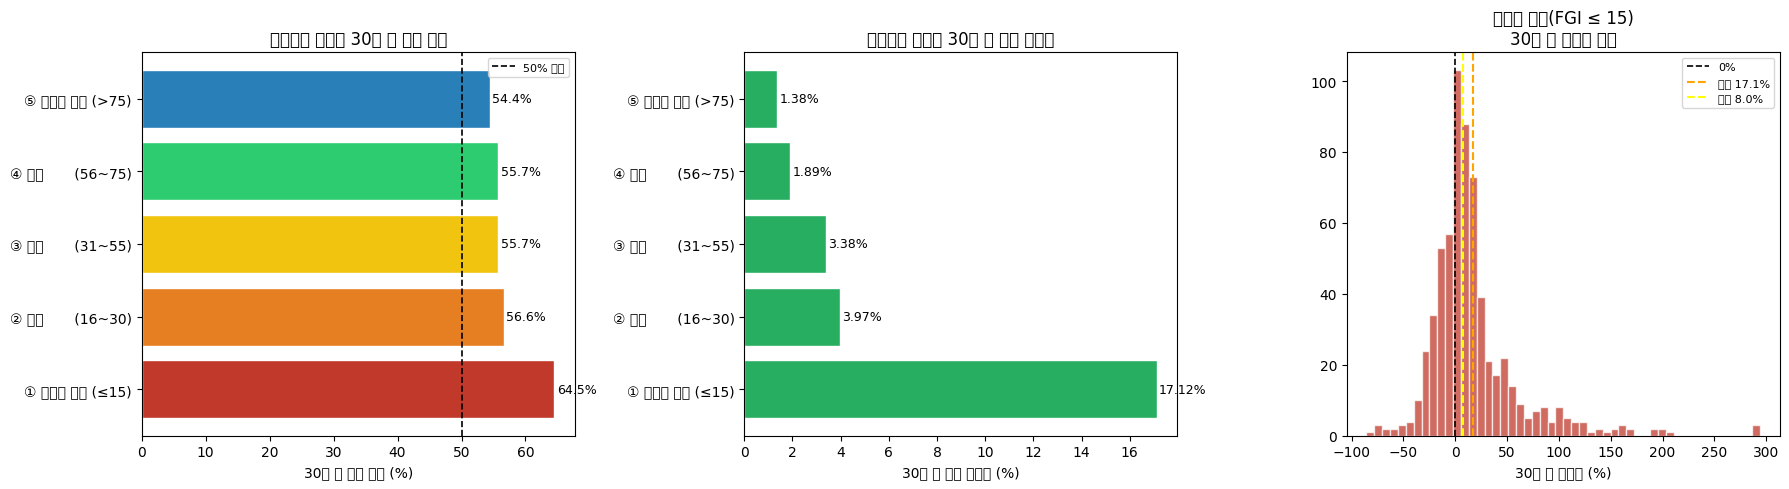

In [147]:
# ============================================================
# 시각화: 구간별 상승확률 & 극단적 공포 수익률 분포
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) 구간별 30일 후 상승 확률
zones     = fg_summary['fg_zone']
win_rates = fg_summary['상승확률_pct']
palette   = ['#c0392b', '#e67e22', '#f1c40f', '#2ecc71', '#2980b9']
bars = axes[0].barh(zones, win_rates, color=palette[:len(zones)], edgecolor='white')
axes[0].axvline(50, color='black', linestyle='--', linewidth=1.2, label='50% 기준')
for bar, v in zip(bars, win_rates):
    axes[0].text(v + 0.4, bar.get_y() + bar.get_height() / 2,
                 f'{v:.1f}%', va='center', fontsize=9)
axes[0].set_xlabel('30일 후 상승 확률 (%)')
axes[0].set_title('공포탐욕 구간별 30일 후 상승 확률')
axes[0].legend(fontsize=8)

# 2) 구간별 평균 수익률
avg_rets = fg_summary['평균수익률_pct']
colors2  = ['#c0392b' if v < 0 else '#27ae60' for v in avg_rets]
axes[1].barh(zones, avg_rets, color=colors2, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.2)
for bar, v in zip(axes[1].patches, avg_rets):
    axes[1].text(v + (0.1 if v >= 0 else -0.1),
                 bar.get_y() + bar.get_height() / 2,
                 f'{v:.2f}%', va='center', ha='left' if v >= 0 else 'right', fontsize=9)
axes[1].set_xlabel('30일 후 평균 수익률 (%)')
axes[1].set_title('공포탐욕 구간별 30일 후 평균 수익률')

# 3) 극단적 공포(≤15) 구간 수익률 분포
ef_rets = fg_hyp[fg_hyp['fg_zone'] == '① 극단적 공포 (≤15)']['return_30d'] * 100
axes[2].hist(ef_rets, bins=50, color='#c0392b', alpha=0.75, edgecolor='white')
axes[2].axvline(0,              color='black',  linestyle='--', linewidth=1.2, label='0%')
axes[2].axvline(ef_rets.mean(), color='orange', linestyle='--', linewidth=1.5,
                label=f'평균 {ef_rets.mean():.1f}%')
axes[2].axvline(ef_rets.median(), color='yellow', linestyle='--', linewidth=1.5,
                label=f'중간 {ef_rets.median():.1f}%')
axes[2].set_xlabel('30일 후 수익률 (%)')
axes[2].set_title('극단적 공포(FGI ≤ 15)\n30일 후 수익률 분포')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [148]:
# ============================================================
# 공포탐욕지수를 ML Feature로 추가 → 모델 재학습 및 성능 비교
# ============================================================

# train 기준일(seq=4411) / test 기준일(seq=4432) FGI 추출
fg_train_feat = (fg_all[fg_all['seq'] == 4411][['symbol', 'fear_greed']]
                 .rename(columns={'fear_greed': 'fear_greed_train'}))
fg_test_feat  = (fg_all[fg_all['seq'] == 4432][['symbol', 'fear_greed']]
                 .rename(columns={'fear_greed': 'fear_greed_test'}))

print(f"train FGI: {fg_train_feat.shape}, 결측: {fg_train_feat['fear_greed_train'].isna().sum()}")
print(f"test  FGI: {fg_test_feat.shape},  결측: {fg_test_feat['fear_greed_test'].isna().sum()}")
print("\ntrain FGI 분포:")
print(fg_train_feat['fear_greed_train'].describe().round(2))

# FGI 포함 X_train
X_train_fg = (
    tmp6.merge(train_peak, on='symbol', how='left')
        .merge(fg_train_feat, on='symbol', how='left')
        .drop(['train_class', 'symbol'], axis=1)
)
y_train_fg = tmp6['train_class']

# FGI 포함 X_test
X_test_fg = (
    tmp7.merge(test_peak, on='symbol', how='left')
        .merge(fg_test_feat, on='symbol', how='left')
        .drop(['test_class', 'symbol'], axis=1)
        .rename(columns={'fear_greed_test': 'fear_greed_train'})  # 컬럼명 일치
)
y_test_fg = tmp7['test_class']

scaler_fg     = StandardScaler()
X_train_fg_sc = scaler_fg.fit_transform(X_train_fg)
X_test_fg_sc  = scaler_fg.transform(X_test_fg)

# --- Decision Tree ---
dt_fg = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_fg.fit(X_train_fg_sc, y_train_fg)
y_pred_dt_fg = dt_fg.predict(X_test_fg_sc)

# --- Random Forest ---
rf_fg = RandomForestClassifier(n_estimators=500, max_depth=5,
                               class_weight='balanced', random_state=42)
rf_fg.fit(X_train_fg, y_train_fg)
y_pred_rf_fg = rf_fg.predict(X_test_fg)

print("\n" + "=" * 50)
print("  Decision Tree (FGI 포함)")
print("=" * 50)
print(f"Accuracy : {accuracy_score(y_test_fg, y_pred_dt_fg):.4f}")
print(classification_report(y_test_fg, y_pred_dt_fg, target_names=['0', '1']))

print("=" * 50)
print("  Random Forest (FGI 포함)")
print("=" * 50)
print(f"Accuracy : {accuracy_score(y_test_fg, y_pred_rf_fg):.4f}")
print(classification_report(y_test_fg, y_pred_rf_fg, target_names=['0', '1']))

# Feature Importance
fi_rf_fg = pd.Series(rf_fg.feature_importances_,
                     index=X_train_fg.columns).sort_values(ascending=False)
print("\nFeature Importance (Top 10):")
print(fi_rf_fg.head(10).round(4).to_string())
fg_rank = fi_rf_fg.index.tolist().index('fear_greed_train') + 1
print(f"\n공포탐욕지수 중요도 순위: {fg_rank}위 ({fi_rf_fg['fear_greed_train']:.4f})")

train FGI: (595, 2), 결측: 0
test  FGI: (595, 2),  결측: 0

train FGI 분포:
count    595.00
mean      59.08
std       11.08
min       16.46
25%       51.85
50%       59.32
75%       67.11
max       81.03
Name: fear_greed_train, dtype: float64

  Decision Tree (FGI 포함)
Accuracy : 0.4446
              precision    recall  f1-score   support

           0       0.42      0.82      0.55       249
           1       0.58      0.17      0.27       347

    accuracy                           0.44       596
   macro avg       0.50      0.50      0.41       596
weighted avg       0.51      0.44      0.39       596

  Random Forest (FGI 포함)
Accuracy : 0.4262
              precision    recall  f1-score   support

           0       0.40      0.78      0.53       249
           1       0.52      0.17      0.26       347

    accuracy                           0.43       596
   macro avg       0.46      0.48      0.40       596
weighted avg       0.47      0.43      0.37       596


Feature Importance (T